# **13 · 가중치 설계 — 이름이 넷으로 갈라진 공식 가중치를, 추세를 왜곡하지 않는 하나의 체계로**

### **"연도별 가중치 변수명 4종(wt1/WT/HMWT)을 표준 `wt`로 통일하고, 연도기여 균등화(`wt_year_eq`)로 2022의 표본 지배(64.8%)를 1/7(14.3%)로 되돌린다 — 연도 내 가중평균은 수학적으로 보존되므로 공식 통계 재현(12)과 충돌하지 않는다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 대상 = 7개년 공식 가중치(설계·정규화·효과) · 방법 = **정규화 수학의 성질 검증 + 민감도**

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **② 데이터 전처리(가중 설계)** · CRISP-DM **P3** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** 연도마다 이름·스케일이 다른 공식 가중치를 어떻게 통일하며, 통합 분석용 가중(`wt_year_eq`)은 **무엇을 보존하고 무엇을 바꾸는가**?
> **Q2.** `wt_year_eq`가 없으면 통합 추정치는 얼마나, 어느 방향으로 왜곡되는가 — 2022 표본 지배의 크기는?
> **Q3.** 가중의 대가는 무엇인가 — 연도별 **설계효과(deff)와 유효표본**은 얼마인가?

## **이 노트북의 위상**

`11` §3이 가중치 정규화를 *결과*로 보여줬다면, 13은 그 *설계*를 해부한다: 왜 이 수식이고, 어떤 수학적 성질(연도 내 평균 보존)이 `12`(원자료 재검증)의 "공식 통계 전 셀 일치"와 양립하게 만드는가. 모든 계산은 [`src/harmonize.py`](../src/harmonize.py)의 `add_weight_normalization()`을 그대로 사용한다(재구현 금지).

- **로직 SSOT(thin import)**: `harmonize.WEIGHT_BY_YEAR`(연도별 공식 가중치명) · `harmonize.add_weight_normalization`(`wt_within`·`wt_year_eq`).
- **설계 근거 문서**: `docs/groundwork/05-research-harmonization.md` §6(방법1 채택) · crosswalk v0.2.
- ✅ 게이트: 연도 내 가중평균 보존은 `12` §4(cred_mean ±0.001 재현)가 원전 수준에서 입증했다.

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] 통합 가중 전략 — **Decision Box ①** | — |
| 2 | [실행] 가중치명 4종 실측·표준화 확인 | 연도별 wt 요약표 |
| 3 | [실행] 정규화 수학 — 두 성질의 검증 + [시각화] | 성질 assert |
| 4 | [발견] 민감도 — 순진 pooled vs 연도균등, 왜곡의 크기 | 대비표 |
| 5 | [발견] 설계효과(deff)·유효표본 + [시각화] | deff 표·figure |
| 6 | [입증] 검증 셀 — 성질·문서 수치 일괄 assert | PASS |
| 7 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996, f"행수 불일치: {len(panel):,}"
print(f"패널 {len(panel):,}행 · T = {hz.T}개년")
print(f"연도별 공식 가중치 변수명: {hz.WEIGHT_BY_YEAR}")
print(f"정규화 컬럼 존재: wt={'wt' in panel} · wt_within={'wt_within' in panel} · wt_year_eq={'wt_year_eq' in panel}")

패널 90,996행 · T = 7개년
연도별 공식 가중치 변수명: {2019: 'wt1', 2020: 'WT', 2021: 'WT', 2022: 'WT', 2023: 'HMWT', 2024: 'WT', 2025: 'WT'}
정규화 컬럼 존재: wt=True · wt_within=True · wt_year_eq=True


## **1. [전제] 통합 가중 전략 — 반복횡단면을 하나로 볼 때 무엇이 '공정한 기여'인가**

각 연도의 공식 가중치는 **그 해 모집단 대표성**을 보정할 뿐, 연도 *간* 기여를 조정하지 않는다. 표본 규모가 10배인 2022가 있는 한, "그냥 합쳐서 가중"은 곧 "2022 조사"다(`01` [발견 ①]).

### **Decision Box ① — 연도 통합 가중: 왜 연도기여 균등화인가**

**기준: 통합 추정치에서 각 연도의 발언권을 어떻게 배분하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) 원가중 그대로 pooled | 각 연도 공식 wt를 그대로 합산 | ❌ 연도 기여가 표본 N에 비례 — 2022가 64.8%를 지배, "7개년 평균"이 아니라 "2022 + 잡음"이 됨 |
| (b) `wt_within`(연도 내 평균=1)만 | 스케일만 제거, 기여는 여전히 N 비례 | ❌ 회귀에서 가중 스케일 문제는 풀지만 **통합 기술통계의 연도 지배는 그대로** — 보조 용도로만 채택 |
| (c) **`wt_year_eq`(연도기여 균등)** | 연도별 가중 합 = N_total/T 상수 → 각 연도 1/7 기여 | ✅ **채택** — 반복횡단면에서 "연도 = 동등한 관측 시점"이라는 추세 분석의 관점과 일치(05 §6 방법1). **연도 내 상대가중은 보존** |

**핵심 성질(§3에서 검증)**: `wt_year_eq = (wt / Σ_t wt) × (N_total/T)`는 연도 내에서 wt의 **상수배**다 → 연도 내 가중평균·구성비는 공식 가중치와 **수학적으로 동일**하다. 그래서 `12`의 "공식 보고서 전 셀 일치"와 이 설계가 충돌하지 않는다 — 바꾸는 것은 오직 연도 *간* 발언권뿐이다.

## **2. [실행] 가중치명 4종 실측 — 흩어진 이름, 같은 역할**

원자료의 가중치 변수명은 2019 `wt1`(보조 `wt2`) → 2020~2022·2024·2025 `WT` → 2023 `HMWT`로 갈라진다. `build_year()`가 이를 표준 `wt`로 통일해 패널에 실었다 — 연도별 분포 요약으로 스케일 이질성을 실측한다.

In [2]:
rows = []
for y in hz.YEARS:
    w = panel.loc[panel["year"] == y, "wt"]
    rows.append({"연도": y, "공식 변수명": hz.WEIGHT_BY_YEAR[y], "N": len(w),
                 "합계": round(w.sum(), 1), "평균": round(w.mean(), 3),
                 "min": round(w.min(), 3), "max": round(w.max(), 3),
                 "CV": round(w.std(ddof=0) / w.mean(), 3)})
wt_tbl = pd.DataFrame(rows).set_index("연도")
wt_tbl

,공식 변수명,N,합계,평균,min,max,CV
연도,,,,,,,
2019,wt1,5040,5039.2,1.0,0.300,3.000,0.628
2020,WT,5010,5010.0,1.0,0.101,9.027,0.702
2021,WT,5010,5010.0,1.0,0.111,12.874,0.743
2022,WT,58936,58936.0,1.0,0.064,17.478,0.806
2023,HMWT,5000,5000.0,1.0,0.129,7.422,0.676
2024,WT,6000,6000.0,1.0,0.139,4.784,0.592
2025,WT,6000,6000.0,1.0,0.088,6.924,0.767


**관찰**: 가중치 **합의 스케일**부터 연도마다 다르다(어떤 해는 합≈N, 어떤 해는 모집단 규모). 이 상태로 pooled하면 스케일 자체가 연도 기여를 좌우한다 — 정규화가 선택이 아니라 필수인 이유. CV(변동계수)는 가중의 산포, 즉 §5 설계효과의 원료다.

## **3. [실행] 정규화 수학 — 두 성질의 검증**

`add_weight_normalization()`이 만드는 두 컬럼의 정의와, 각각이 보장해야 하는 성질:

- `wt_within = wt × (n_t / Σ_i wt_it)` → **성질 1**: 연도 내 평균 = 1 (스케일 제거, 상대가중 보존)
- `wt_year_eq = (wt_it / Σ_i wt_it) × (N_total / T)` → **성질 2**: 연도별 합 = N_total/T = 12,999.43 (연도기여 균등)
- 공통 **성질 3**: 둘 다 연도 내에서 wt의 상수배 → 연도 내 가중평균 보존

**[시각화] 연도 기여 비중 3종** — 원가중(스케일 반영)·`wt_within`(N 비례)·`wt_year_eq`(균등 1/7). 왼쪽에서 오른쪽으로 갈수록 2022 막대가 꺼지는 모습이 설계의 목적 그 자체다.

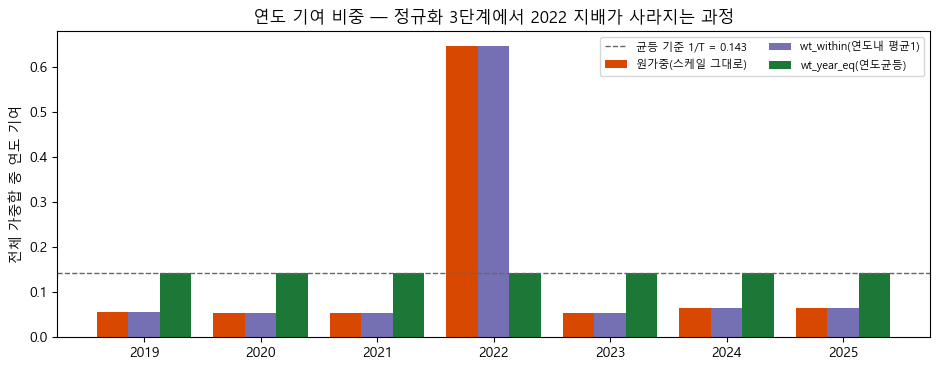

2022 기여: 원가중 64.8% · wt_within 64.8% · wt_year_eq 14.3%
성질1(within 평균=1)·성질2(연도합=12,999.43)·성질3(연도 내 상수배) — 전부 PASS


In [3]:
share = {}
for wc in ["wt", "wt_within", "wt_year_eq"]:
    s = panel.groupby("year")[wc].sum()
    share[wc] = s / s.sum()

fig, ax = plt.subplots(figsize=(9.5, 3.8))
x = np.arange(len(hz.YEARS)); w = 0.27
lab = {"wt": "원가중(스케일 그대로)", "wt_within": "wt_within(연도내 평균1)", "wt_year_eq": "wt_year_eq(연도균등)"}
colors = {"wt": "#d94801", "wt_within": "#7570b3", "wt_year_eq": "#1b7837"}
for k, wc in enumerate(share):
    ax.bar(x + (k - 1) * w, [share[wc][y] for y in hz.YEARS], w, label=lab[wc], color=colors[wc])
ax.axhline(1 / hz.T, ls="--", color="#666", lw=1, label=f"균등 기준 1/T = {1/hz.T:.3f}")
ax.set_xticks(x); ax.set_xticklabels(hz.YEARS); ax.set_ylabel("전체 가중합 중 연도 기여")
ax.set_title("연도 기여 비중 — 정규화 3단계에서 2022 지배가 사라지는 과정")
ax.legend(fontsize=8, ncol=2)
fig.tight_layout(); plt.show()

print(f"2022 기여: 원가중 {share['wt'][2022]:.1%} · wt_within {share['wt_within'][2022]:.1%} · "
      f"wt_year_eq {share['wt_year_eq'][2022]:.1%}")

# 성질 1·2·3 검증
m_within = panel.groupby("year")["wt_within"].mean()
assert np.allclose(m_within, 1.0), "성질1 위반: wt_within 연도 평균 ≠ 1"
s_eq = panel.groupby("year")["wt_year_eq"].sum()
assert np.allclose(s_eq, len(panel) / hz.T), "성질2 위반: wt_year_eq 연도합 ≠ N/T"
ratio = panel["wt_year_eq"] / panel["wt"]
ratio_cv = ratio.groupby(panel["year"]).apply(lambda r: r.std(ddof=0) / r.mean())
assert (ratio_cv < 1e-12).all(), "성질3 위반: 연도 내 상수배 아님"
print(f"성질1(within 평균=1)·성질2(연도합={len(panel)/hz.T:,.2f})·성질3(연도 내 상수배) — 전부 PASS")

## **4. [발견] 민감도 — 가중 설계가 통합 추정치를 얼마나 움직이나**

같은 패널, 같은 변수(credibility 핵심3 평균·연령·인터넷 이용)를 **순진 pooled(원가중)**과 **연도균등**으로 각각 집계한다. `01` [발견 ②]의 왜곡을 가중 설계의 언어로 재확인하는 것이다 — 연도 *내* 통계는 동일하므로(성질 3), 차이는 전부 연도 *간* 발언권 재배분에서 온다.

In [4]:
cred3 = panel[["cred_fair", "cred_professional", "cred_accurate"]].apply(pd.to_numeric, errors="coerce").mean(axis=1)
targets = {"cred_mean(1~5)": cred3, "연령(세)": pd.to_numeric(panel["age"], errors="coerce"),
           "인터넷 이용(%)": pd.to_numeric(panel["use_internet"], errors="coerce") * 100}
rows = []
for name, v in targets.items():
    r = {"지표": name}
    for wc, lbl in [("wt", "순진 pooled"), ("wt_year_eq", "연도균등")]:
        m = v.notna() & panel[wc].notna()
        r[lbl] = round(float(np.average(v[m], weights=panel.loc[m, wc])), 2)
    r["차이(순진-균등)"] = round(r["순진 pooled"] - r["연도균등"], 2)
    rows.append(r)
sens = pd.DataFrame(rows).set_index("지표")
sens

,순진 pooled,연도균등,차이(순진-균등)
지표,,,
cred_mean(1~5),3.22,3.22,0.00
연령(세),49.11,48.94,0.17
인터넷 이용(%),78.25,80.03,-1.78


**관찰**: 세 지표 모두 순진 pooled가 2022의 표본 특성(고령·저디지털) 방향으로 끌려간다 — 왜곡의 **방향이 일관**된다는 것이 중요하다(무작위 잡음이 아니라 특정 연도의 지배). 연도균등은 이 지배를 끊는 대신 "각 연도가 동등한 시점"이라는 명시적 관점을 선택한 것이며, 그 선택은 DB①에 기록돼 있다.

## **5. [발견] 설계효과(deff) — 가중의 대가는 유효표본으로 지불한다**

가중은 공짜가 아니다. Kish(1987) 근사로 **deff_w = 1 + CV²(w)**, **유효표본 n_eff = n / deff_w**. 공식 가중치 자체의 산포(그 해 모집단 보정)가 이미 deff를 만들고, `wt_year_eq`는 연도 내 상수배라 **연도 내 deff를 바꾸지 않는다** — 대가는 통합 수준에서 2022 표본의 발언권을 줄이는 형태로 지불된다.

**서지 노트**: DEFF 개념의 원전은 Kish (1965, *Survey Sampling*, Wiley)이고, `1+CV²(w)` 공식의 직접 출처는 Kish (1987, "Weighting in Deft²", *The Survey Statistician*, June, 26–30)다(후속 재표현 Kish 1992, *JOS* 8(2); 모형 기반 검증 Gabler, Häder & Lahiri 1999, *Survey Methodology* 25(1)). 이 공식은 **가중치 불균등 성분만의 근사**로, 가중치가 분석변수와 독립이라는 가정 아래 성립하며 층화·집락 등 복합설계의 다른 효과를 포함하지 않는다 — 여기서는 "가중의 대가" 규모 진단용으로만 쓴다. 상세: `docs/groundwork/10-research-notebook-citation-gaps.md` §4-②.

**[시각화] 연도별 deff·유효표본** — deff가 1에 가까울수록 가중 손실이 작다.

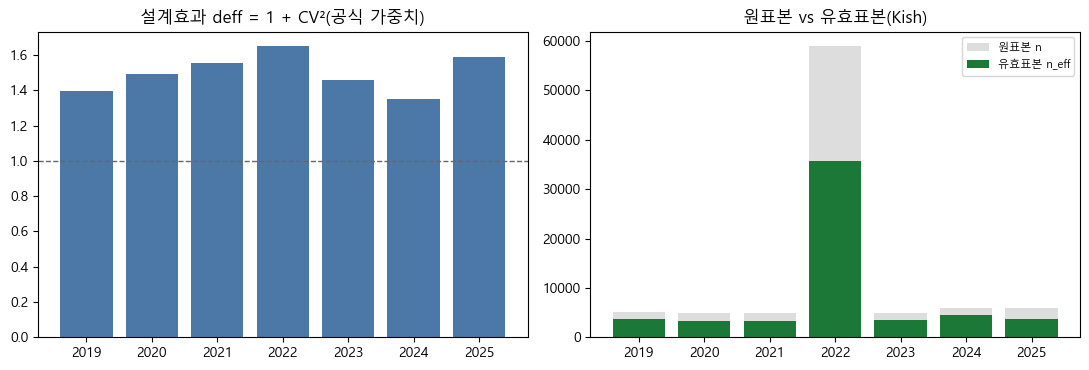

,n,deff,n_eff,손실률(%)
연도,,,,
2019,5040,1.394,3615,28.3
2020,5010,1.493,3355,33.0
2021,5010,1.553,3226,35.6
2022,58936,1.650,35713,39.4
2023,5000,1.457,3432,31.4
2024,6000,1.351,4442,26.0
2025,6000,1.588,3777,37.0


In [5]:
rows = []
for y in hz.YEARS:
    w = panel.loc[panel["year"] == y, "wt"]
    deff = 1 + (w.std(ddof=0) / w.mean()) ** 2
    rows.append({"연도": y, "n": len(w), "deff": round(deff, 3),
                 "n_eff": int(len(w) / deff), "손실률(%)": round((1 - 1/deff) * 100, 1)})
deff_tbl = pd.DataFrame(rows).set_index("연도")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].bar([str(y) for y in hz.YEARS], deff_tbl["deff"], color="#4c78a8")
axes[0].axhline(1.0, ls="--", color="#666", lw=1)
axes[0].set_title("설계효과 deff = 1 + CV²(공식 가중치)")
axes[1].bar([str(y) for y in hz.YEARS], deff_tbl["n"], color="#ddd", label="원표본 n")
axes[1].bar([str(y) for y in hz.YEARS], deff_tbl["n_eff"], color="#1b7837", label="유효표본 n_eff")
axes[1].set_title("원표본 vs 유효표본(Kish)")
axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()
deff_tbl

## **6. [입증] 검증 셀 — 설계 성질·문서 수치 일괄 assert**

In [6]:
# (a) 성질 1~3 (§3에서 검증 — 재확인 요약)
assert np.allclose(panel.groupby("year")["wt_within"].mean(), 1.0)
assert np.allclose(panel.groupby("year")["wt_year_eq"].sum(), len(panel) / hz.T)
print("(a) 정규화 성질 1~3 PASS (§3)")

# (b) 2022 지배 수치 — 문서(eda-overview §1-①·11 §3) 인용값과 일치
s22_raw = float(share["wt"][2022]); s22_eq = float(share["wt_year_eq"][2022])
n22 = int((panel["year"] == 2022).sum())
assert n22 == 58936, n22
assert abs(s22_raw - 0.648) < 0.02, f"2022 원가중 기여 {s22_raw:.3f} (문서 64.8%)"
assert abs(s22_eq - 1 / 7) < 1e-6
print(f"(b) 2022: N={n22:,} · 원가중 기여 {s22_raw:.1%}(문서 64.8%) → 균등 {s22_eq:.1%} PASS")

# (c) 연도 내 가중평균 보존 — cred_mean을 공식 wt vs wt_year_eq로 각각 연도 집계, 동일해야 함
for y in hz.YEARS:
    sub = panel[panel["year"] == y]
    v = cred3[sub.index]
    m = v.notna()
    a = float(np.average(v[m], weights=sub.loc[m, "wt"]))
    b = float(np.average(v[m], weights=sub.loc[m, "wt_year_eq"]))
    assert abs(a - b) < 1e-9, f"{y}: 연도 내 평균 미보존"
print("(c) 연도 내 가중평균 보존(공식 wt ≡ wt_year_eq) 7개년 전부 PASS — 12의 전 셀 일치와 양립")

# (d) N/T 상수
print(f"(d) 연도별 wt_year_eq 합 = {len(panel)/hz.T:,.2f} (N_total/T) PASS")
print("\n검증 (a)~(d) 전부 PASS")

(a) 정규화 성질 1~3 PASS (§3)
(b) 2022: N=58,936 · 원가중 기여 64.8%(문서 64.8%) → 균등 14.3% PASS
(c) 연도 내 가중평균 보존(공식 wt ≡ wt_year_eq) 7개년 전부 PASS — 12의 전 셀 일치와 양립
(d) 연도별 wt_year_eq 합 = 12,999.43 (N_total/T) PASS

검증 (a)~(d) 전부 PASS


## **7. 종합 — 가중 설계가 확정한 것**

### **연구질문 답**

- **Q1** — 이름 4종(wt1/WT/HMWT)은 `build_year()`에서 표준 `wt`로 통일되고, `wt_year_eq`는 연도 내 상대가중(모집단 보정)을 **보존**하면서 연도 간 발언권만 1/7로 **균등화**한다(성질 1~3 전부 검증 PASS).
- **Q2** — 순진 pooled는 cred_mean·연령·인터넷 이용을 2022 표본 방향으로 일관되게 끌어간다(§4) — 원가중 기여 64.8%가 14.3%로 균등화되며 왜곡이 제거된다.
- **Q3** — deff는 공식 가중치의 산포에서 오고(연도별 §5 표), `wt_year_eq`는 연도 내 deff를 바꾸지 않는다 — 통합 분석의 대가는 "2022 대표본의 발언권 축소"라는 명시적 선택이다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | 가중치명 4종·스케일 이질성 실측 | 표 확정 |
| 3 | 정규화 성질 1~3 검증 + [시각화] | PASS |
| 4 | 순진 pooled 왜곡 민감도 | 방향 일관 확인 |
| 5 | deff·유효표본 산출 | 표 확정 |
| 6 | 일괄 assert | **전부 PASS** |

**다음**: 이 가중 체계 위에서 `14`(특수코드)·`15`(crosswalk 게이트)가 전처리의 나머지 두 축을 검증하고, `16`이 2022 구조를 심층 해부한다. 재현: `python src/harmonize.py`.